In [258]:
from IPython.display import display, HTML, Markdown

<div style="background-image: linear-gradient(135deg, #886893, #152f64, #fba1c2); padding: 20px; border-radius: 10px;">
    <p style="font-size: 40px; font-weight:bold; font-family: 'Georgia'; color: #ffffff; text-align: center;">🎙️ Predicting Podcast Stardom: A Data Science Adventure</p></div>

Welcome to my notebook for the Playground Series S5E4!
Today, we're diving into the buzzing world of podcasts — predicting their popularity based on all things content, hosts, guests, and vibes.

Grab your headphones 🎧 and let's get started!

<center>
    <img src='https://64.media.tumblr.com/07a456407883c6276f2e674d529020c3/8cfab903b5143759-30/s1280x1920/4586077796df568c9aa7d3df43e1ab85eb8f0c29.pnj' style="width: 350px; height: 250px; border-radius: 10px; box-shadow: 5px 5px 15px rgba(0, 0, 0, 0.1);">
</center>

<div style="background-image: linear-gradient(135deg,#152f64, #886893); padding: 20px; border-radius: 10px;">
    <p style="font-size: 20px; font-weight:bold; font-family: 'Georgia'; color: #ffffff; text-align: center;">📚 Importing Libraries: Setting the Forecasting Station!📦</p></div>

First, let’s bring in all the tools we need — from scikit-learn superheroes to seaborn’s artsy side.
(Also setting up a custom palette, because pretty plots = happy brain!)

In [259]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [260]:
#customising the palette

saniya_palette = [
    "#fba1c2", "#152f64", "#886893", "#fff3f8", "#e58ab5",
    "#5c4b85", "#30477f", "#d88fad", "#cab0d5", "#9e7fb3",
    "#3f5d96", "#ffcadb", "#6f5a92", "#a3c3eb", "#b87aa7"
]

sns.set_palette(saniya_palette) #for setting the default palette

In [261]:
#custom cmap palette
import matplotlib.colors as mlc
saniya_pal=mlc.LinearSegmentedColormap.from_list("custom",["#fba1c2", "#152f64"])

<div style="background-image: linear-gradient(135deg,#fba1c2, #886893); padding: 20px; border-radius: 10px;">
    <p style="font-size: 20px; font-weight:bold; font-family: 'Georgia'; color: white; text-align: center;"> 🧹 Cleaning the Mic: Data Preprocessing</p></div>

Good podcasts need good sound.
Good models need good data.

Here we:

Check for missing values (and fix them if needed)

Tidy up categorical columns

Get numbers ready for machine learning magic



In [262]:
data=pd.read_csv('/kaggle/input/playground-series-s5e4/train.csv')
data2=pd.read_csv('/kaggle/input/playground-series-s5e4/test.csv')
df=pd.DataFrame(data)
df2=pd.DataFrame(data2)

In [263]:
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058
749996,749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939


In [264]:
#id and index is same
df=df.drop(columns=['id'])
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...
749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058
749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242
749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939


In [265]:
df.dtypes

Podcast_Name                    object
Episode_Title                   object
Episode_Length_minutes         float64
Genre                           object
Host_Popularity_percentage     float64
Publication_Day                 object
Publication_Time                object
Guest_Popularity_percentage    float64
Number_of_Ads                  float64
Episode_Sentiment               object
Listening_Time_minutes         float64
dtype: object

In [266]:
df.shape

(750000, 11)

In [267]:
df.nunique()

Podcast_Name                      48
Episode_Title                    100
Episode_Length_minutes         12268
Genre                             10
Host_Popularity_percentage      8038
Publication_Day                    7
Publication_Time                   4
Guest_Popularity_percentage    10019
Number_of_Ads                     12
Episode_Sentiment                  3
Listening_Time_minutes         42807
dtype: int64

In [268]:
#splitting into two columns
df[['Episode','Title']]=df['Episode_Title'].str.split(' ',n=1, expand=True)

In [269]:
df=df.drop(columns=['Episode_Title','Episode'])

In [270]:
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Podcast_Name,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes,Title
0,Mystery Matters,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998,98
1,Joke Junction,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241,26
2,Study Sessions,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531,16
3,Digital Digest,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824,45
4,Mind & Body,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031,86
...,...,...,...,...,...,...,...,...,...,...,...
749995,Learning Lab,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058,25
749996,Business Briefs,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242,21
749997,Lifestyle Lounge,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000,51
749998,Style Guide,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939,47


In [271]:
df.isnull().sum()

Podcast_Name                        0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
Title                               0
dtype: int64

In [272]:
df['Title']=df['Title'].apply(lambda x:int(x))

<div style="background-image: linear-gradient(135deg,#886893, #fff3f8); padding: 20px; border-radius: 10px;">
    <p style="font-size: 20px; font-weight:bold; font-family: 'Georgia'; color: #152f64; text-align: center;"> 📊 Visualizing the Podcast Playground :EDA 🎨 </p></div>

Because graphs tell better stories than tables!
Some juicy insights from the visuals:

25-minute episodes are the sweet spot 🕒

Hosts with 30%-70% popularity feel just right — neither TikTok-famous nor totally unknown

Guests with moderate fame (50%-70%) strike the perfect credibility balance

People love jumping onto series between 30–35 or 60–70 episodes. Binge alert! 🍿

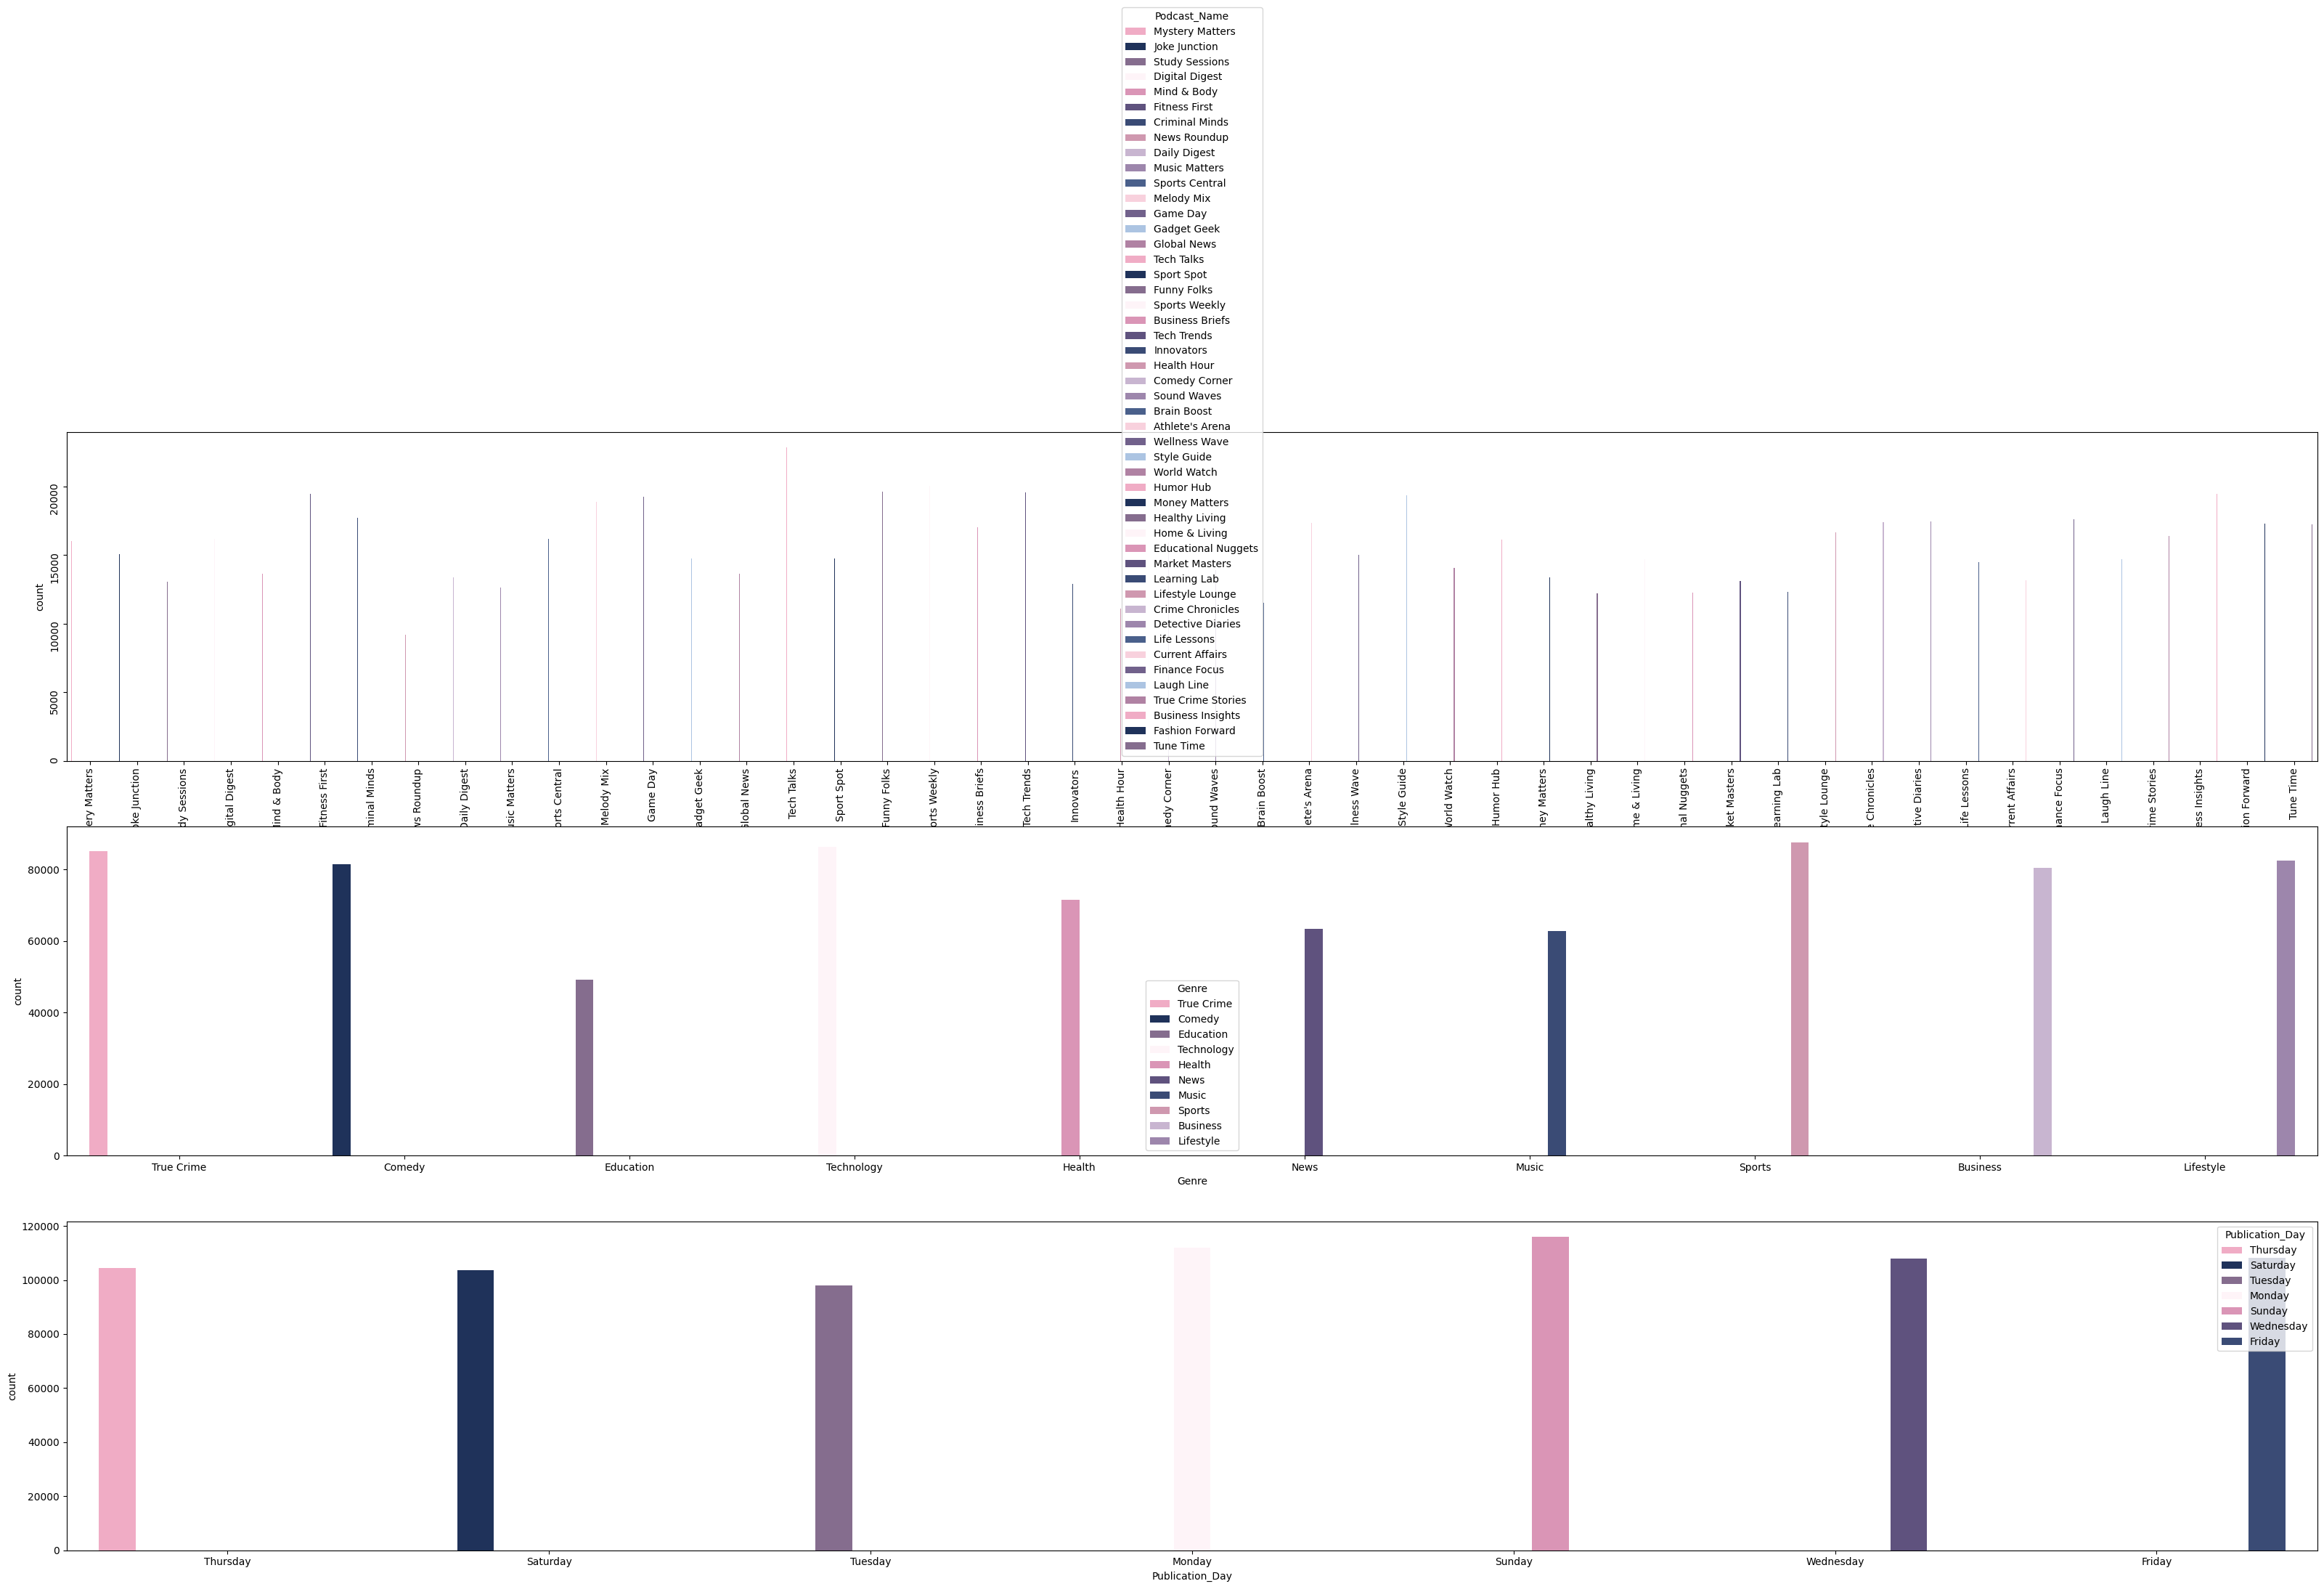

In [273]:
fig,ax=plt.subplots(3,1,figsize=(40,20))
sns.countplot(x='Podcast_Name',data=df,hue='Podcast_Name',palette=saniya_palette,ax=ax[0])
ax[0].tick_params(rotation=90)
sns.countplot(x='Genre',data=df,hue='Genre',palette=saniya_palette,ax=ax[1])
ax[0].tick_params(rotation=90)
sns.countplot(x='Publication_Day',data=df,hue='Publication_Day',palette=saniya_palette,ax=ax[2])
ax[0].tick_params(rotation=90)
plt.show()

from this graph, we can infer that the most streamed podcast is 'Tech Trends' and the most popular genre is sports, followed closely by true crime. In terms of publication day, Sunday ranks first while Monday follows a close second.

/tmp/ipykernel_31/672171984.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df,x='Episode_Length_minutes',palette=saniya_palette,ax=ax[0,0],bins=10,kde=True)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_31/672171984.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df,x='Host_Popularity_percentage',palette=saniya_palette,ax=ax[0,1],bins=10,kde=True)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_31/672171984.py:6: UserWarnin

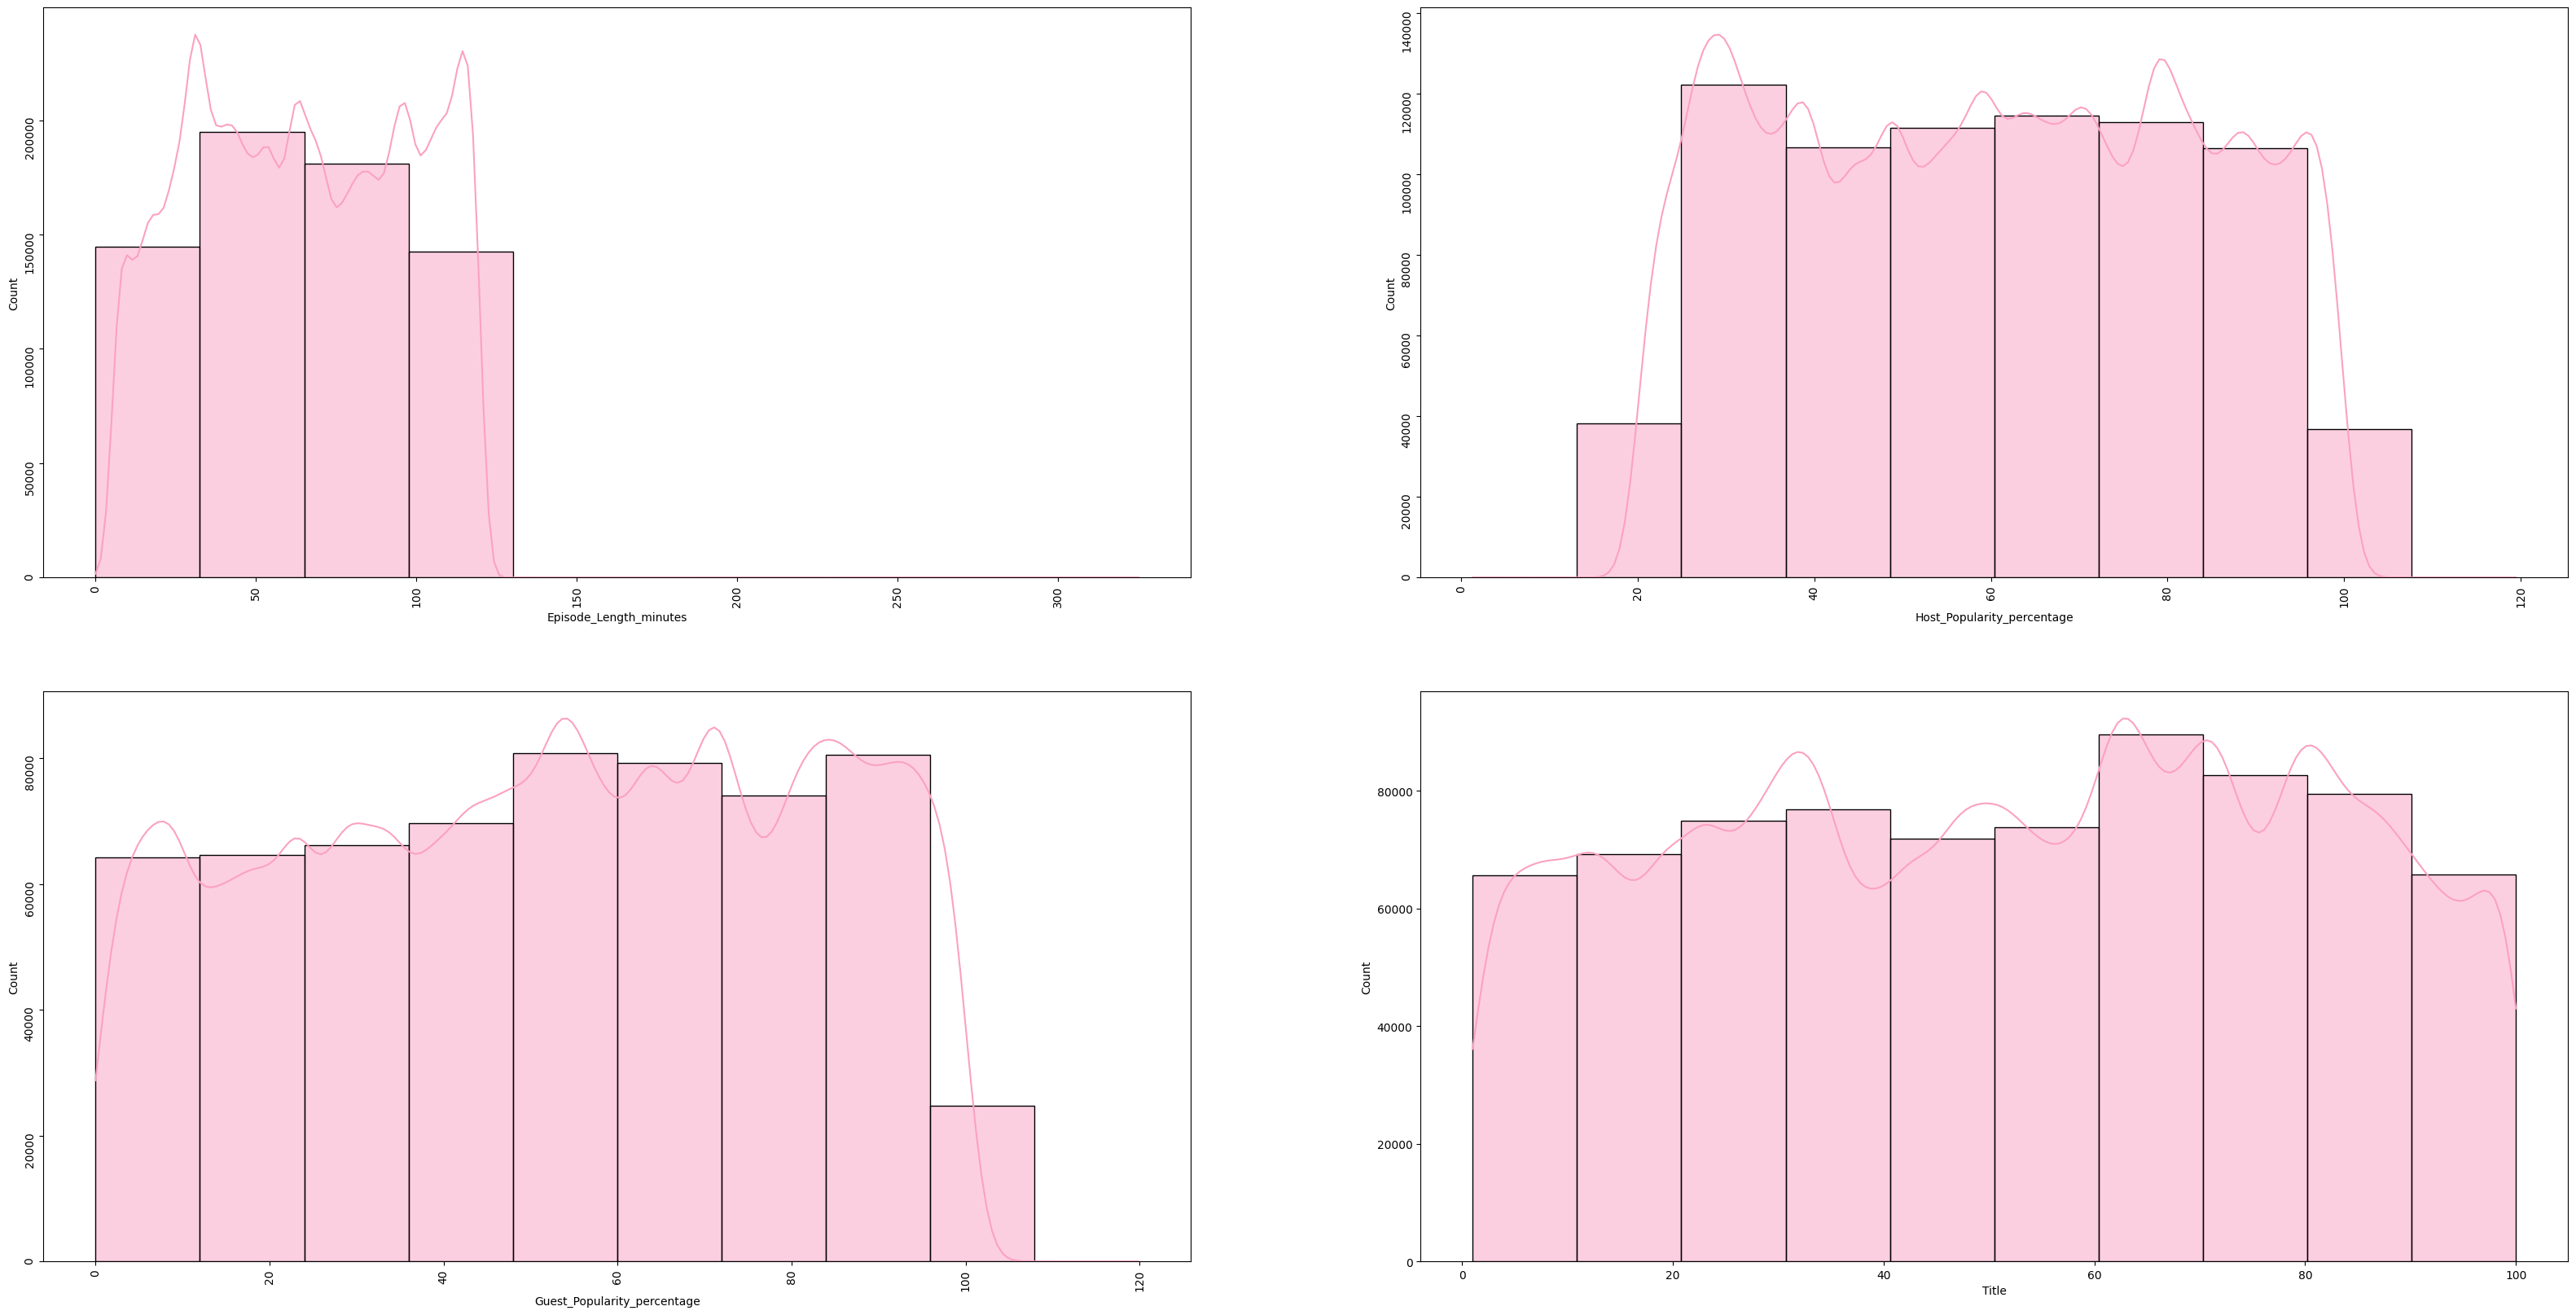

In [274]:
fig,ax=plt.subplots(2,2,figsize=(40,20))
sns.histplot(data=df,x='Episode_Length_minutes',palette=saniya_palette,ax=ax[0,0],bins=10,kde=True)
ax[0,0].tick_params(rotation=90)
sns.histplot(data=df,x='Host_Popularity_percentage',palette=saniya_palette,ax=ax[0,1],bins=10,kde=True)
ax[0,1].tick_params(rotation=90)
sns.histplot(data=df,x='Guest_Popularity_percentage',palette=saniya_palette,ax=ax[1,0],bins=10,kde=True)
ax[1,0].tick_params(rotation=90)
sns.histplot(data=df,x='Title',palette=saniya_palette,ax=ax[1,1],bins=10,kde=True)
ax[1,0].tick_params(rotation=90)
plt.show()

From these graphs, we can arrive at the following interpretations:<br>
-25 minute episodes are highly popular.<br>
-Host popularity is an inverse factor where hosts with 30% popularity upto 70% are preferred as lesser popular ones seem to have weak crediblity as per the audience and the more popular ones might have more influence than relevant information.<br>
-In terms of guest popularity, 50% popularity is ideal case scenario with some preferring around 70% too, while the graph dips at around 100% as people will not prefer influencers or popular celebrities as it becomes more of a showbizz and view-farming content than real information. In contrast, people are more inclined towards lesser popular guests as they represent the niche sphere of the respective field.<br>
-As per the episode number, the peaks are seen at the 30-35 episode mark and the 60-70 episode mark as these could be seen as more developed content and people get onboard a series towards the end so it's easier to binge-watch.<br>

<Axes: xlabel='Episode_Sentiment', ylabel='count'>

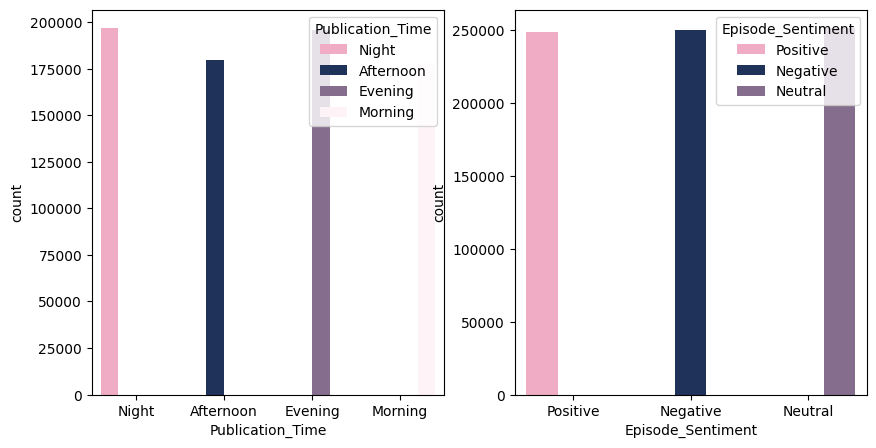

In [275]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
sns.countplot(x='Publication_Time',data=df,hue='Publication_Time',palette=saniya_palette,ax=ax[0])
#ax[0].tick_params(rotation=90)
sns.countplot(x='Episode_Sentiment',data=df,hue='Episode_Sentiment',palette=saniya_palette,ax=ax[1])
#ax[0].tick_params(rotation=90)

These graphs tell us that:<br>
-Most streams are from Night and Evening times as it's the time people unwind and relax for the day.<br>
-Positive content is lesser preferred than near equal Neutral and Negative Sentiment.

/tmp/ipykernel_31/887103233.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x='Listening_Time_minutes',palette=saniya_palette,bins=50,kde=True)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


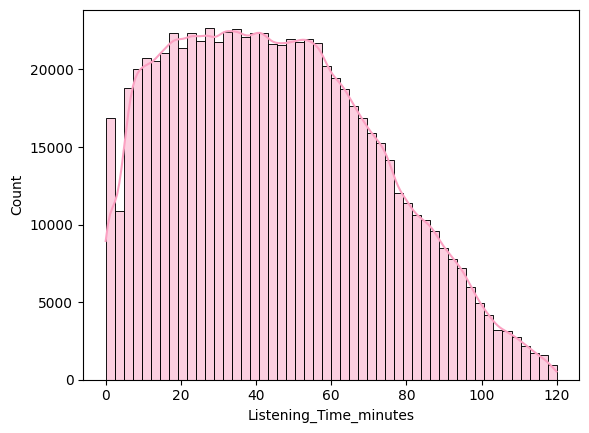

In [276]:
sns.histplot(data=df, x='Listening_Time_minutes',palette=saniya_palette,bins=50,kde=True)
plt.show()

The bell-graph shows us that the data is skewed to the left, suggesting that there is a higher count of short-term listeners than long term ones which in an ideal scenario would prove to be false.

In [277]:
#dividing the listening time into two categories, for plotting
mean=df['Listening_Time_minutes'].mean()
df['Listener_Type']=df['Listening_Time_minutes'].apply(lambda x: "Long_Term" if x>mean else "Short_Term")
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Podcast_Name,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes,Title,Listener_Type
0,Mystery Matters,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998,98,Short_Term
1,Joke Junction,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241,26,Long_Term
2,Study Sessions,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531,16,Short_Term
3,Digital Digest,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824,45,Long_Term
4,Mind & Body,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031,86,Long_Term
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,Learning Lab,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058,25,Long_Term
749996,Business Briefs,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242,21,Long_Term
749997,Lifestyle Lounge,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000,51,Short_Term
749998,Style Guide,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939,47,Long_Term


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


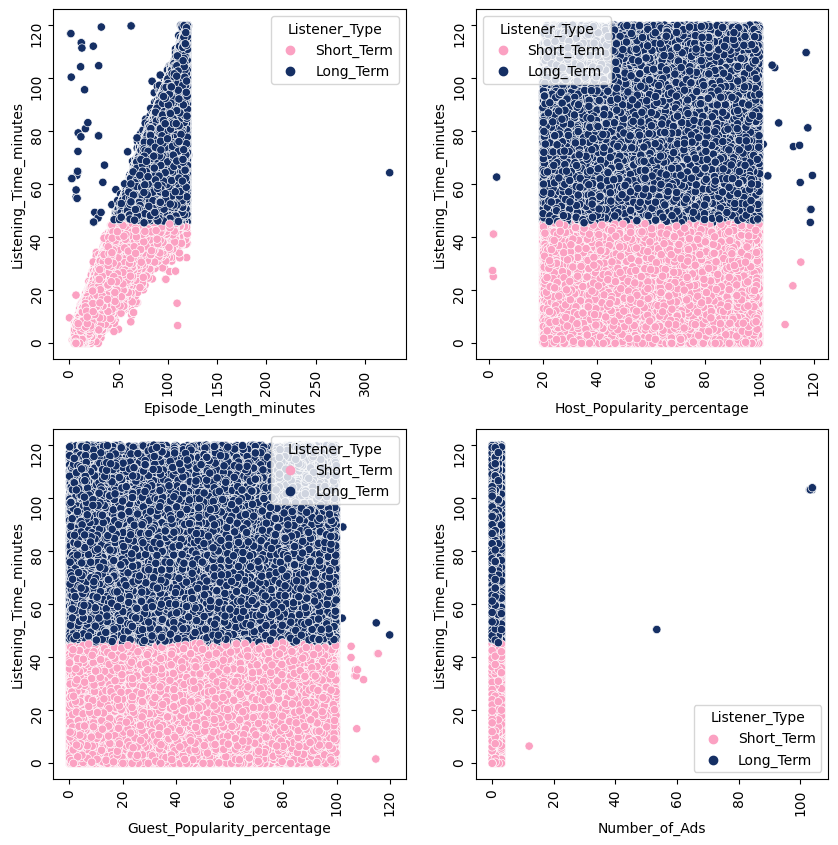

In [278]:
#Bi-variate Analysis
fig,ax=plt.subplots(2,2,figsize=(10,10))
sns.scatterplot(x=df['Episode_Length_minutes'],y=df['Listening_Time_minutes'],hue=df['Listener_Type'],ax=ax[0,0])
ax[0,0].tick_params(rotation=90)
sns.scatterplot(x=df['Host_Popularity_percentage'],y=df['Listening_Time_minutes'],hue=df['Listener_Type'],ax=ax[0,1])
ax[0,1].tick_params(rotation=90)
sns.scatterplot(x=df['Guest_Popularity_percentage'],y=df['Listening_Time_minutes'],hue=df['Listener_Type'],ax=ax[1,0])
ax[1,0].tick_params(rotation=90)
sns.scatterplot(x=df['Number_of_Ads'],y=df['Listening_Time_minutes'],hue=df['Listener_Type'],ax=ax[1,1])
ax[1,1].tick_params(rotation=90)
plt.show()

As per these graphs:<br>
-There's a positive correlation between length of an episode and the listening time.<br>
-Most of the host popularity is condensed between 20-100 %.<br>
-Guest popularity doesn't seem to have any regression.<br>
-Most of the listening times are condensed at 0-2 ads.<br>

<div style="background-image: linear-gradient(135deg,#152f64, #fba1c2); padding: 20px; border-radius: 10px;">
    <p style="font-size: 20px; font-weight:bold; font-family: 'Georgia'; color: white; text-align: center;">🛠️ Engineering Some Podcast Magic: Feature Engineering</p></div>

Now comes the part where we create features the models will actually love:

Encoding strings into numbers

Handling skewed features

Trying interaction terms between episode length, host/guest popularity, etc.

In [279]:
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Podcast_Name,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes,Title,Listener_Type
0,Mystery Matters,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998,98,Short_Term
1,Joke Junction,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241,26,Long_Term
2,Study Sessions,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531,16,Short_Term
3,Digital Digest,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824,45,Long_Term
4,Mind & Body,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031,86,Long_Term
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,Learning Lab,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058,25,Long_Term
749996,Business Briefs,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242,21,Long_Term
749997,Lifestyle Lounge,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000,51,Short_Term
749998,Style Guide,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939,47,Long_Term


In [280]:
#imputation(filling in the null values)
df.isnull().sum()

Podcast_Name                        0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
Title                               0
Listener_Type                       0
dtype: int64

In [281]:
df['Episode_Length_minutes']=df['Episode_Length_minutes'].fillna(value=df['Episode_Length_minutes'].mean())
df['Guest_Popularity_percentage']=df['Guest_Popularity_percentage'].fillna(value=df['Guest_Popularity_percentage'].mean())
df['Number_of_Ads']=df['Number_of_Ads'].fillna(value=df['Number_of_Ads'].mean())
df['Number_of_Ads']=df['Number_of_Ads'].apply(lambda x:int(x))

In [282]:
df.isnull().sum()

Podcast_Name                   0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Listening_Time_minutes         0
Title                          0
Listener_Type                  0
dtype: int64

In [283]:
def feat_eng(df):
    df['Host/Guest']=df['Host_Popularity_percentage']/(df['Guest_Popularity_percentage']+1) #to avoid divide by 0 error.
    df['Interval_Length']=df['Episode_Length_minutes']/(df['Number_of_Ads']+1)
    df['Segments']=df['Number_of_Ads']+1
    #day and time relation
    df['Day_Time']=df['Publication_Day']/df['Publication_Time']
    #commercial effect 
    df['Host_Ads']=df['Host_Popularity_percentage']*df['Number_of_Ads']
    df['Guest_Ads']=df['Guest_Popularity_percentage']*df['Number_of_Ads']
    return df
    

In [284]:
mapping = { #map the values to new values
    "Monday": 1,
    "Tuesday": 2,
    "Wednesday": 3,
    "Thursday": 4,
    "Friday": 5,
    "Saturday": 6,
    "Sunday": 7,
}

df["Publication_Day"] = df["Publication_Day"].map(mapping)

In [285]:
mapping2 = { #map the values to new values
    "Morning": 1,
    "Afternoon": 2,
    "Evening": 3,
    "Night": 4,
}

df["Publication_Time"] = df["Publication_Time"].map(mapping2)

In [286]:
df=feat_eng(df)
df

,Podcast_Name,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes,Title,Listener_Type,Host/Guest,Interval_Length,Segments,Day_Time,Host_Ads,Guest_Ads
0,Mystery Matters,64.504738,True Crime,74.81,4,4,52.236449,0,Positive,31.41998,98,Short_Term,1.405240,64.504738,1,1.000000,0.00,0.000000
1,Joke Junction,119.800000,Comedy,66.95,6,2,75.950000,2,Negative,88.01241,26,Long_Term,0.870045,39.933333,3,3.000000,133.90,151.900000
2,Study Sessions,73.900000,Education,69.97,2,3,8.970000,0,Negative,44.92531,16,Short_Term,7.018054,73.900000,1,0.666667,0.00,0.000000
3,Digital Digest,67.170000,Technology,57.22,1,1,78.700000,2,Positive,46.27824,45,Long_Term,0.717942,22.390000,3,1.000000,114.44,157.400000
4,Mind & Body,110.510000,Health,80.07,1,2,58.680000,3,Neutral,75.61031,86,Long_Term,1.341655,27.627500,4,0.500000,240.21,176.040000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,Learning Lab,75.660000,Education,69.36,6,1,52.236449,0,Negative,56.87058,25,Long_Term,1.302867,75.660000,1,6.000000,0.00,0.000000
749996,Business Briefs,75.750000,Business,35.21,6,4,52.236449,2,Neutral,45.46242,21,Long_Term,0.661389,25.250000,3,1.500000,70.42,104.472898
749997,Lifestyle Lounge,30.980000,Lifestyle,78.58,4,1,84.890000,0,Negative,15.26000,51,Short_Term,0.914891,30.980000,1,4.000000,0.00,0.000000
749998,Style Guide,108.980000,Lifestyle,45.39,4,1,93.270000,0,Negative,100.72939,47,Long_Term,0.481489,108.980000,1,4.000000,0.00,0.000000


/tmp/ipykernel_31/1500978194.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df,x='Host/Guest',palette=saniya_palette,ax=ax[0],bins=50,kde=True)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_31/1500978194.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df,x='Interval_Length',palette=saniya_palette,ax=ax[1],bins=10,kde=True)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


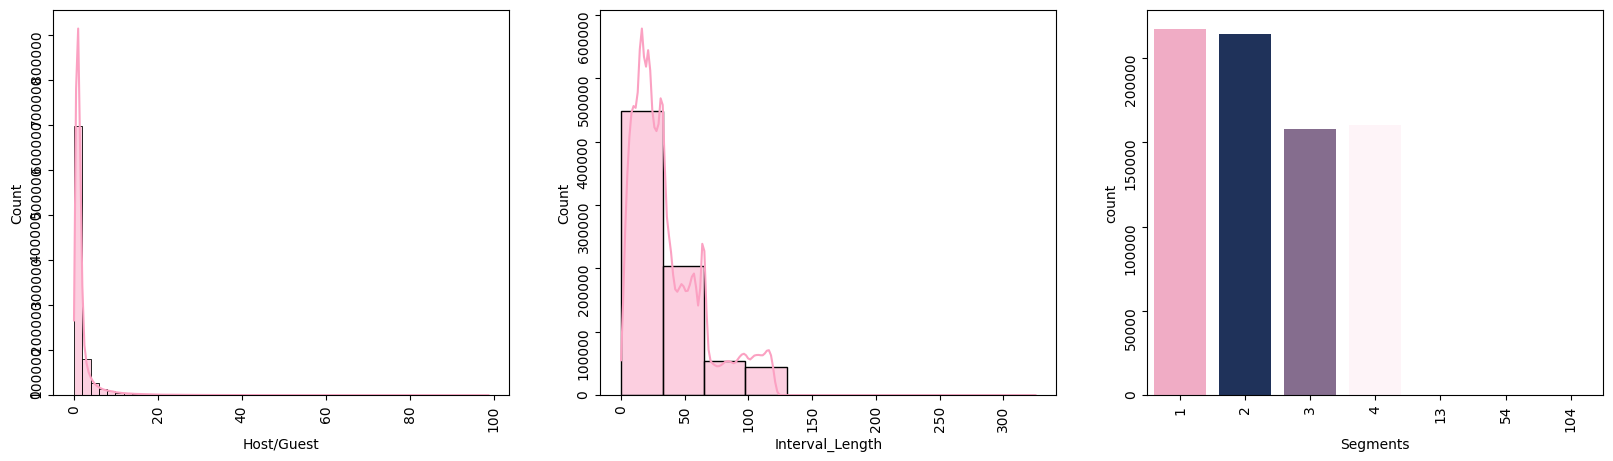

In [287]:
#EDA 2
fig,ax=plt.subplots(1,3,figsize=(20,5))
sns.histplot(data=df,x='Host/Guest',palette=saniya_palette,ax=ax[0],bins=50,kde=True)
ax[0].tick_params(rotation=90)
sns.histplot(data=df,x='Interval_Length',palette=saniya_palette,ax=ax[1],bins=10,kde=True)
ax[1].tick_params(rotation=90)
sns.countplot(data=df,x='Segments',palette=saniya_palette,ax=ax[2])
ax[2].tick_params(rotation=90)

These graphs tell us that:<br>
-People prefer popular guests over popular hosts, since the ratio of 0-0.5 has a high frequency in the data.<br>
-Most streamers prefer episode length or slices of 20-25 minutes as that is the standard maximum attention span of an adult.<br>
-People highly prefer 1-2 segments as it is shorter and crisp to the point.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


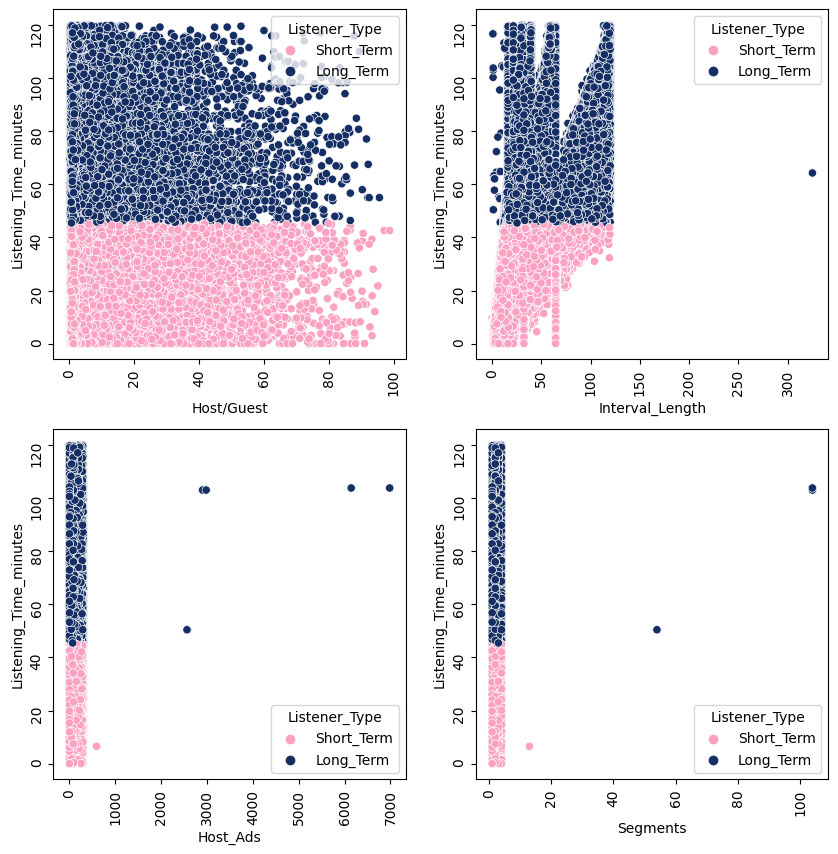

In [288]:
#Bivariate analysis 2
fig,ax=plt.subplots(2,2,figsize=(10,10))
sns.scatterplot(x=df['Host/Guest'],y=df['Listening_Time_minutes'],hue=df['Listener_Type'],ax=ax[0,0])
ax[0,0].tick_params(rotation=90)
sns.scatterplot(x=df['Interval_Length'],y=df['Listening_Time_minutes'],hue=df['Listener_Type'],ax=ax[0,1])
ax[0,1].tick_params(rotation=90)
sns.scatterplot(x=df['Host_Ads'],y=df['Listening_Time_minutes'],hue=df['Listener_Type'],ax=ax[1,0])
ax[1,0].tick_params(rotation=90)
sns.scatterplot(x=df['Segments'],y=df['Listening_Time_minutes'],hue=df['Listener_Type'],ax=ax[1,1])
ax[1,1].tick_params(rotation=90)
plt.show()

<div style="background-image: linear-gradient(135deg, #fba1c2, #152f64); padding: 20px; border-radius: 10px;">
    <p style="font-size: 20px; font-weight:bold; font-family: 'Georgia'; color: white; text-align: center;"> 🎯 Encoding the Data: Label Encoding</p></div>

In [289]:
from sklearn.preprocessing import LabelEncoder

In [290]:
df.dtypes

Podcast_Name                    object
Episode_Length_minutes         float64
Genre                           object
Host_Popularity_percentage     float64
Publication_Day                  int64
Publication_Time                 int64
Guest_Popularity_percentage    float64
Number_of_Ads                    int64
Episode_Sentiment               object
Listening_Time_minutes         float64
Title                            int64
Listener_Type                   object
Host/Guest                     float64
Interval_Length                float64
Segments                         int64
Day_Time                       float64
Host_Ads                       float64
Guest_Ads                      float64
dtype: object

In [291]:
le=LabelEncoder()
cols=['Podcast_Name','Genre','Episode_Sentiment','Listener_Type']

for col in cols:
    df[col]=le.fit_transform(df[col])

In [292]:
df

,Podcast_Name,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes,Title,Listener_Type,Host/Guest,Interval_Length,Segments,Day_Time,Host_Ads,Guest_Ads
0,34,64.504738,9,74.81,4,4,52.236449,0,2,31.41998,98,1,1.405240,64.504738,1,1.000000,0.00,0.000000
1,24,119.800000,1,66.95,6,2,75.950000,2,0,88.01241,26,0,0.870045,39.933333,3,3.000000,133.90,151.900000
2,40,73.900000,2,69.97,2,3,8.970000,0,0,44.92531,16,1,7.018054,73.900000,1,0.666667,0.00,0.000000
3,10,67.170000,8,57.22,1,1,78.700000,2,2,46.27824,45,0,0.717942,22.390000,3,1.000000,114.44,157.400000
4,31,110.510000,3,80.07,1,2,58.680000,3,1,75.61031,86,0,1.341655,27.627500,4,0.500000,240.21,176.040000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,26,75.660000,2,69.36,6,1,52.236449,0,0,56.87058,25,0,1.302867,75.660000,1,6.000000,0.00,0.000000
749996,2,75.750000,0,35.21,6,4,52.236449,2,1,45.46242,21,0,0.661389,25.250000,3,1.500000,70.42,104.472898
749997,28,30.980000,4,78.58,4,1,84.890000,0,0,15.26000,51,1,0.914891,30.980000,1,4.000000,0.00,0.000000
749998,41,108.980000,4,45.39,4,1,93.270000,0,0,100.72939,47,0,0.481489,108.980000,1,4.000000,0.00,0.000000


### Outlier Removal

In [293]:
from scipy import stats

z = np.abs(stats.zscore(df))

threshold = 3

#columns with outliers
cols = ['Interval_Length','Host_Ads', 'Guest_Ads','Host_Popularity_percentage','Guest_Popularity_percentage','Number_of_Ads']

#removing outliers
df = df[(z < 3).all(axis=1)]

In [294]:
df.shape

(734578, 18)

### Hypothesis Testing

Null Hypothesis: Listening time is independent of number of segments.<br>
Anti-Null Hypothesis: Listening time is dependent on number of segments.

In [295]:
#chi squared test for segments
from scipy.stats import chi2_contingency

#sample data
samp=df.head(100)
data_c=pd.crosstab(df['Segments'],df['Listening_Time_minutes'], margins=False)
#data_s=pd.crosstab(samp['Listening_Time_minutes'],samp['Segments'], margins=False)
data_c

Listening_Time_minutes,0.00000,0.00056,0.00175,0.00661,0.01050,0.01077,0.01257,0.02960,0.03228,0.03430,...,119.56000,119.66000,119.67000,119.73000,119.74000,119.78000,119.79000,119.80000,119.90000,119.97000
Segments,,,,,,,,,,,,,,,,,,,,,
1,1557,2,1,6,1,2,3,9,2,6,...,6,0,1,4,1,1,2,14,5,2
2,3668,0,0,0,0,15,2,4,3,10,...,8,13,5,5,9,8,10,4,11,12
3,1431,2,3,4,3,0,2,1,7,0,...,1,0,4,4,1,1,1,0,0,5
4,1701,3,3,7,3,6,21,1,4,2,...,2,8,1,0,4,7,0,0,0,3


In [296]:
stat,p, dof, expected= chi2_contingency(data_c)
print('stat=%.3f,p=%.3f' % (stat,p))

stat=441457.725,p=0.000


Since p<0.05, we reject the null hypothesis.

<div style="background-image: linear-gradient(135deg,#152f64, #886893); padding: 20px; border-radius: 10px;">
    <p style="font-size: 20px; font-weight:bold; font-family: 'Georgia'; color: white; text-align: center;"> 🤖 Model Time! Which Podcast is Listened to the Most? </p></div>

Let’s see who predicts the podcast world like a true mind reader 🔮

<Axes: >

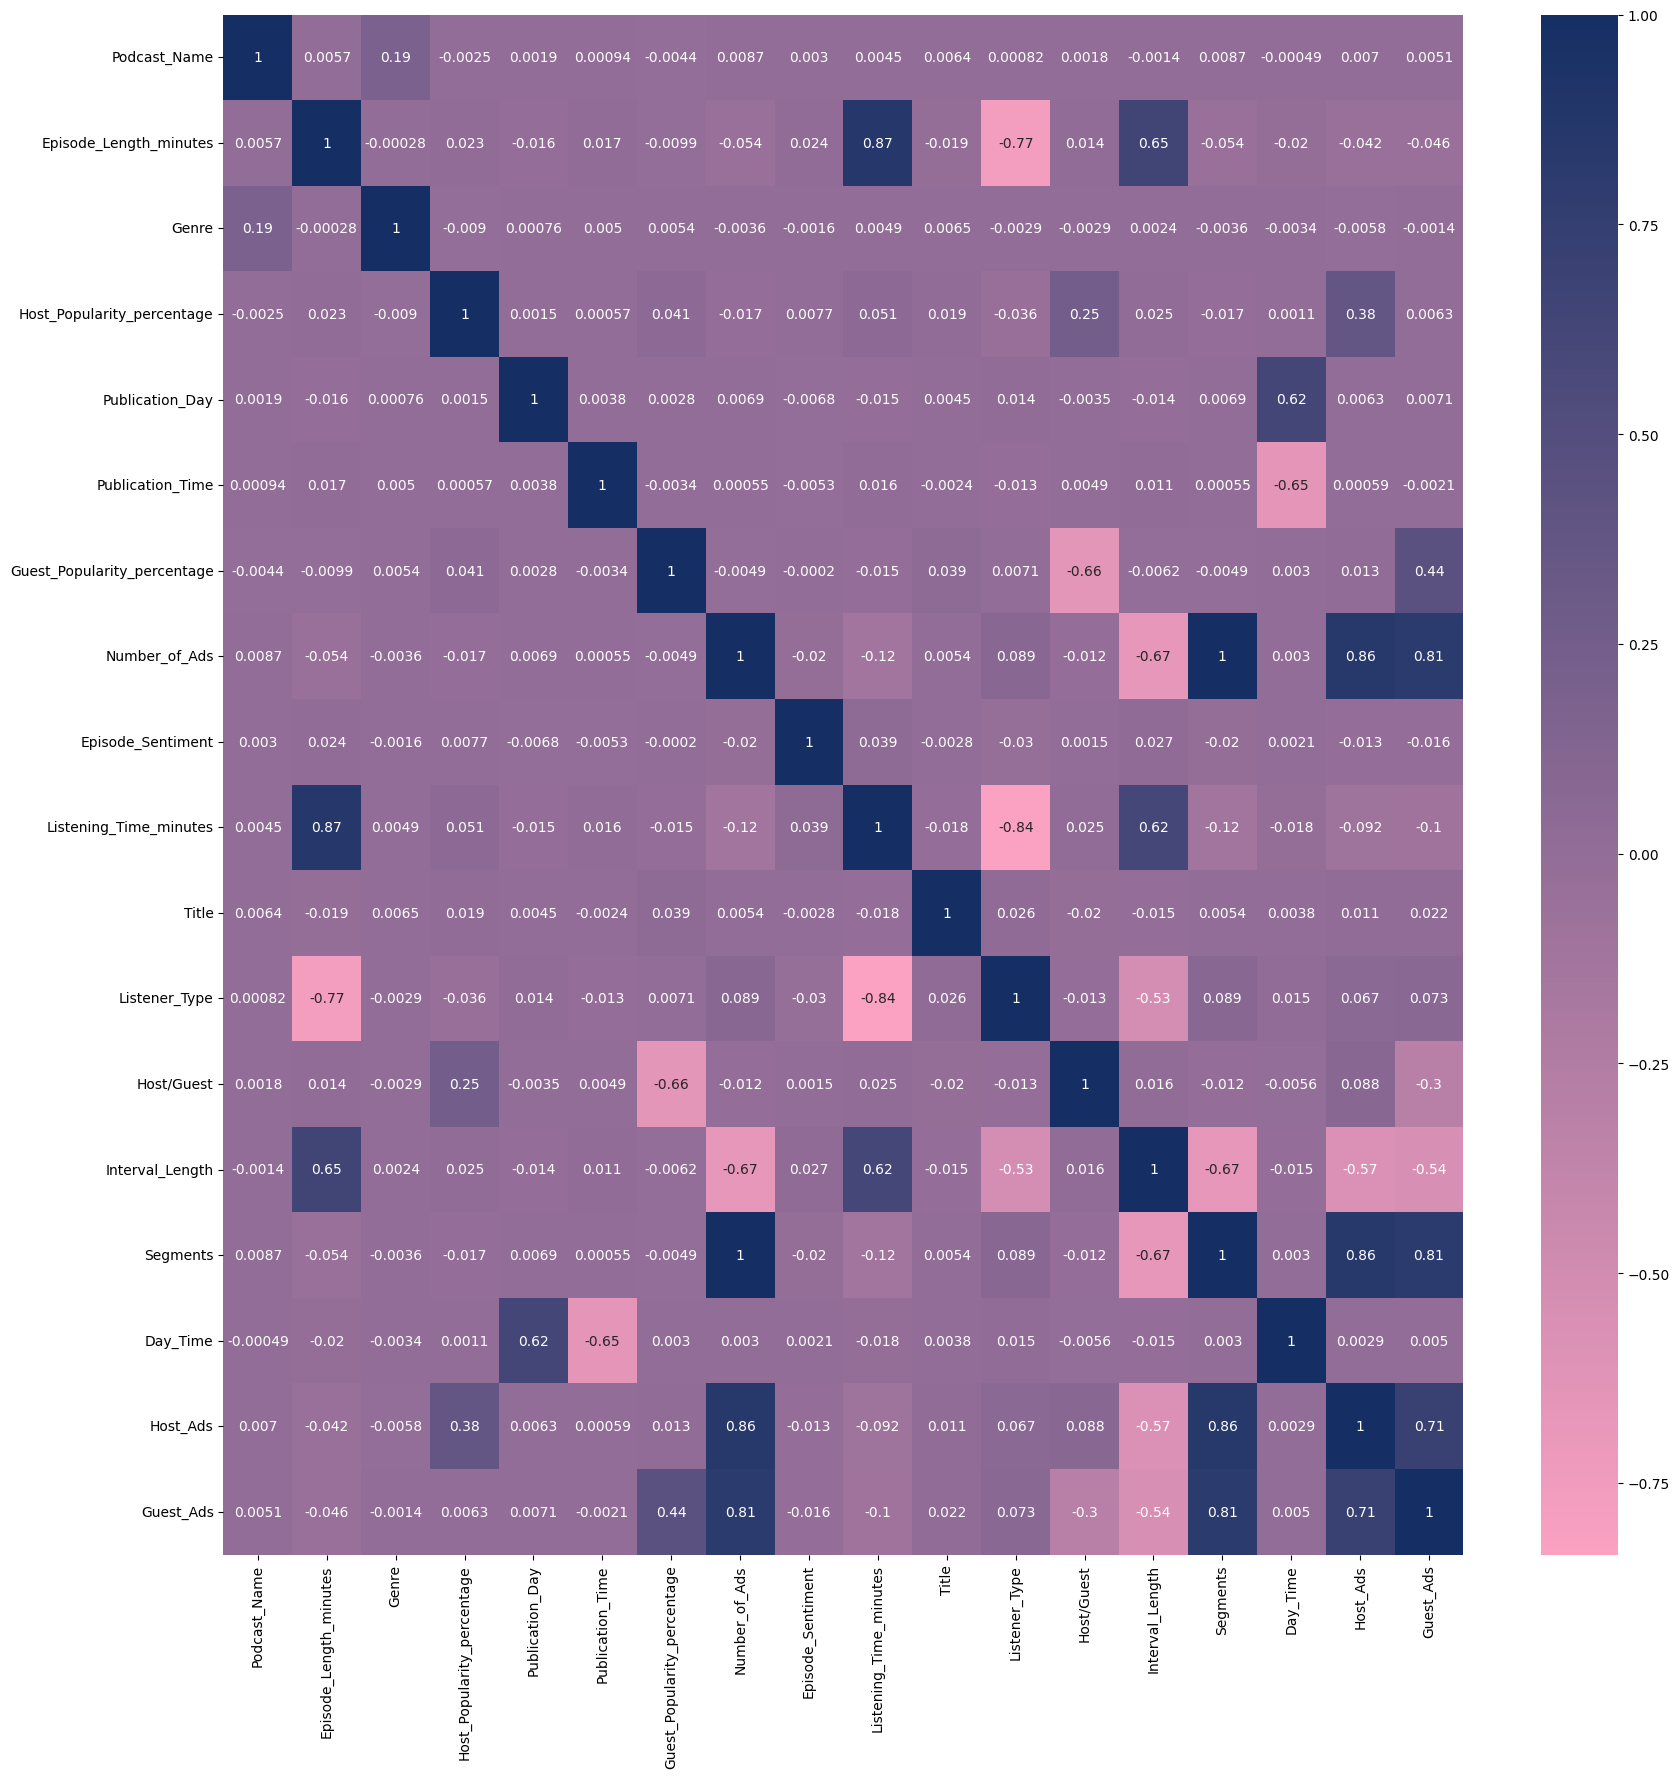

In [297]:
fig,ax=plt.subplots(1,1,figsize=(20,20))
sns.heatmap(df.corr(),annot=True, cmap=saniya_pal)

<div style="background-image: linear-gradient(135deg,#886893, #fba1c2); padding: 20px; border-radius: 10px;">
    <p style="font-size: 20px; font-weight:bold; font-family: 'Georgia'; color: white; text-align: left;">Model Training</p></div>

In [298]:
import lightgbm as lgbm

In [299]:
lgb=lgbm.LGBMRegressor(n_estimators=100)

In [300]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [301]:
x=df.drop(columns=['Listening_Time_minutes','Listener_Type'])
y=df['Listening_Time_minutes']

In [302]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.4, random_state=42)

In [303]:
## Feature Selection

#initially wanted to get only the most important features but it was affecting the performance, indicating under-fitting.

from mlxtend.feature_selection import SequentialFeatureSelector
f_feat_selec=SequentialFeatureSelector(lgbm.LGBMRegressor(n_jobs=-1), #try without standardising,accuracy only for classification
                                      k_features=10,
                                      verbose=2,
                                      forward=True,
                                      floating=False,
                                      scoring='neg_mean_squared_error',
                                      cv=5
                                      ).fit(x_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001198 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 48
[LightGBM] [Info] Number of data points in the train set: 352596, number of used features: 1
[LightGBM] [Info] Start training from score 45.458886
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001214 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 48
[LightGBM] [Info] Number of data points in the train set: 352597, number of used features: 1
[LightGBM] [Info] Start training from score 45.491463
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002920 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins


[2025-04-30 09:14:12] Features: 1/10 -- score: -182.49819759978797

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001998 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 303
[LightGBM] [Info] Number of data points in the train set: 352596, number of used features: 2
[LightGBM] [Info] Start training from score 45.458886
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 303
[LightGBM] [Info] Number of data points in the train set: 352597, number of used features: 2
[LightGBM] [Info] Start training from score 45.491463
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002181 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug


[2025-04-30 09:15:32] Features: 2/10 -- score: -176.3062419148186

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006607 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 558
[LightGBM] [Info] Number of data points in the train set: 352596, number of used features: 3
[LightGBM] [Info] Start training from score 45.458886
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006492 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 558
[LightGBM] [Info] Number of data points in the train set: 352597, number of used features: 3
[LightGBM] [Info] Start training from score 45.491463
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002638 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 558
[LightGBM] [Info] Number of data points in the train set:

...


[2025-04-30 09:22:55] Features: 8/10 -- score: -171.93427339747012

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005262 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1190
[LightGBM] [Info] Number of data points in the train set: 352596, number of used features: 9
[LightGBM] [Info] Start training from score 45.458886
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004959 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1190
[LightGBM] [Info] Number of data points in the train set: 352597, number of used features: 9
[LightGBM] [Info] Start training from score 45.491463
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not eno


[2025-04-30 09:24:00] Features: 9/10 -- score: -171.90912381884866

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006218 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1195
[LightGBM] [Info] Number of data points in the train set: 352596, number of used features: 10
[LightGBM] [Info] Start training from score 45.458886
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005841 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1195
[LightGBM] [Info] Number of data points in the train set: 352597, number of used features: 10
[LightGBM] [Info] Start training from score 45.491463
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e


[2025-04-30 09:25:02] Features: 10/10 -- score: -171.85860738270642

In [304]:
f_feat_selec.k_feature_names_

('Podcast_Name',
 'Episode_Length_minutes',
 'Host_Popularity_percentage',
 'Publication_Day',
 'Publication_Time',
 'Guest_Popularity_percentage',
 'Episode_Sentiment',
 'Title',
 'Interval_Length',
 'Host_Ads')

In [305]:
df_copy=df[['Podcast_Name',
 'Episode_Length_minutes',
 'Host_Popularity_percentage',
 'Publication_Day',
 'Publication_Time',
 'Guest_Popularity_percentage',
 'Episode_Sentiment',
 'Title',
 'Interval_Length',
 'Host_Ads']]

In [306]:
x=df_copy
y=df['Listening_Time_minutes']

In [307]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.6, random_state=42)

<div style="background-image: linear-gradient(135deg,#886893, #fba1c2); padding: 20px; border-radius: 10px;">
    <p style="font-size: 20px; font-weight:bold; font-family: 'Georgia'; color: white; text-align: left;">Re-Training the Model</p></div>

In [308]:
from sklearn.preprocessing import StandardScaler
stan=StandardScaler()
x_train=stan.fit_transform(x_train)
x_test=stan.transform(x_test)

In [309]:
lgb.fit(x_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004547 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1442
[LightGBM] [Info] Number of data points in the train set: 293831, number of used features: 10
[LightGBM] [Info] Start training from score 45.478950


LGBMRegressor()

In [310]:
pred=lgb.predict(x_test)

In [311]:
pred

array([12.44823745, 27.6360806 , 12.48694411, ..., 64.48698134,
        8.91013061, 22.0498326 ])

In [312]:
from sklearn.metrics import r2_score,mean_squared_error
from math import sqrt
r2_score(y_test, pred)
sqrt(mean_squared_error(y_test, pred))

13.124016799214921

<div style="background-image: linear-gradient(135deg,#152f64, #fff3f8); padding: 20px; border-radius: 10px;">
    <p style="font-size: 20px; font-weight:bold; font-family: 'Georgia'; color: white; text-align: left;">HyperTuning the Model</p></div>

In [313]:
from sklearn.model_selection import GridSearchCV

#parameters for grid search
param_grid = {
    "num_leaves": [27, 31, 63, 127],
    "max_depth": [-1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}
# Grid Search Object
grid = GridSearchCV(lgb, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)

#fitting the grid search
grid.fit(x_train, y_train)

#best parameters
print(grid.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.063882 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1442
[LightGBM] [Info] Number of data points in the train set: 235064, number of used features: 10
[LightGBM] [Info] Start training from score 45.482961
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052444 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1442
[LightGBM] [Info] Number of data points in the train set: 235065, number of used features: 10
[LightGBM] [Info] Start training from score 45.430281
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034734 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1442
[LightGBM] [Info] Number of data points in the train s

In [335]:
#Applying the tuning
lgb=lgbm.LGBMRegressor(n_estimators=100, colsample_bytree= 0.8, max_depth= -1, num_leaves= 127, subsample= 0.8)

In [336]:
lgb.fit(x_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1442
[LightGBM] [Info] Number of data points in the train set: 293831, number of used features: 10
[LightGBM] [Info] Start training from score 45.478950


LGBMRegressor(colsample_bytree=0.8, num_leaves=127, subsample=0.8)

In [337]:
pred=lgb.predict(x_test)

In [338]:
pred

array([12.97128603, 27.96117883, 11.97699869, ..., 64.3707593 ,
        9.58687879, 21.63966766])

In [339]:
r2_score(y_test, pred)
sqrt(mean_squared_error(y_test, pred))

13.071727676301924

## Preparing the Test Data

In [340]:
df_test=pd.read_csv('/kaggle/input/playground-series-s5e4/test.csv')

In [341]:
df_test

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral
...,...,...,...,...,...,...,...,...,...,...,...
249995,999995,Mind & Body,Episode 100,21.05,Health,65.77,Saturday,Evening,96.40,3.0,Negative
249996,999996,Joke Junction,Episode 85,85.50,Comedy,41.47,Saturday,Night,30.52,2.0,Negative
249997,999997,Joke Junction,Episode 63,12.11,Comedy,25.92,Thursday,Evening,73.69,1.0,Neutral
249998,999998,Market Masters,Episode 46,113.46,Business,43.47,Friday,Night,93.59,3.0,Positive


In [342]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           250000 non-null  int64  
 1   Podcast_Name                 250000 non-null  object 
 2   Episode_Title                250000 non-null  object 
 3   Episode_Length_minutes       221264 non-null  float64
 4   Genre                        250000 non-null  object 
 5   Host_Popularity_percentage   250000 non-null  float64
 6   Publication_Day              250000 non-null  object 
 7   Publication_Time             250000 non-null  object 
 8   Guest_Popularity_percentage  201168 non-null  float64
 9   Number_of_Ads                250000 non-null  float64
 10  Episode_Sentiment            250000 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 21.0+ MB


In [343]:
df_test=df_test.drop(columns=['id'])
df_test

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
2,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral
...,...,...,...,...,...,...,...,...,...,...
249995,Mind & Body,Episode 100,21.05,Health,65.77,Saturday,Evening,96.40,3.0,Negative
249996,Joke Junction,Episode 85,85.50,Comedy,41.47,Saturday,Night,30.52,2.0,Negative
249997,Joke Junction,Episode 63,12.11,Comedy,25.92,Thursday,Evening,73.69,1.0,Neutral
249998,Market Masters,Episode 46,113.46,Business,43.47,Friday,Night,93.59,3.0,Positive


In [344]:
#splitting into two columns
df_test[['Episode','Title']]=df_test['Episode_Title'].str.split(' ',n=1, expand=True)

In [345]:
df_test=df_test.drop(columns=['Episode_Title','Episode'])

In [346]:
df_test.isnull().sum()
df_test['Title']=df_test['Title'].apply(lambda x:int(x))
df_test['Episode_Length_minutes']=df_test['Episode_Length_minutes'].fillna(value=df_test['Episode_Length_minutes'].mean())
df_test['Guest_Popularity_percentage']=df_test['Guest_Popularity_percentage'].fillna(value=df_test['Guest_Popularity_percentage'].mean())
df_test

,Podcast_Name,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Title
0,Educational Nuggets,78.96,Education,38.11,Saturday,Evening,53.330000,1.0,Neutral,73
1,Sound Waves,27.87,Music,71.29,Sunday,Morning,52.192796,0.0,Neutral,23
2,Joke Junction,69.10,Comedy,67.89,Friday,Evening,97.510000,0.0,Positive,11
3,Comedy Corner,115.39,Comedy,23.40,Sunday,Morning,51.750000,2.0,Positive,73
4,Life Lessons,72.32,Lifestyle,58.10,Wednesday,Morning,11.300000,2.0,Neutral,50
...,...,...,...,...,...,...,...,...,...,...
249995,Mind & Body,21.05,Health,65.77,Saturday,Evening,96.400000,3.0,Negative,100
249996,Joke Junction,85.50,Comedy,41.47,Saturday,Night,30.520000,2.0,Negative,85
249997,Joke Junction,12.11,Comedy,25.92,Thursday,Evening,73.690000,1.0,Neutral,63
249998,Market Masters,113.46,Business,43.47,Friday,Night,93.590000,3.0,Positive,46


In [347]:
df_test["Publication_Day"] = df_test["Publication_Day"].map(mapping)
df_test["Publication_Time"] = df_test["Publication_Time"].map(mapping2)

In [348]:
df_test=feat_eng(df_test)

In [349]:
df_test

,Podcast_Name,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Title,Host/Guest,Interval_Length,Segments,Day_Time,Host_Ads,Guest_Ads
0,Educational Nuggets,78.96,Education,38.11,6,3,53.330000,1.0,Neutral,73,0.701454,39.480000,2.0,2.000000,38.11,53.33
1,Sound Waves,27.87,Music,71.29,7,1,52.192796,0.0,Neutral,23,1.340219,27.870000,1.0,7.000000,0.00,0.00
2,Joke Junction,69.10,Comedy,67.89,5,3,97.510000,0.0,Positive,11,0.689169,69.100000,1.0,1.666667,0.00,0.00
3,Comedy Corner,115.39,Comedy,23.40,7,1,51.750000,2.0,Positive,73,0.443602,38.463333,3.0,7.000000,46.80,103.50
4,Life Lessons,72.32,Lifestyle,58.10,3,1,11.300000,2.0,Neutral,50,4.723577,24.106667,3.0,3.000000,116.20,22.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,Mind & Body,21.05,Health,65.77,6,3,96.400000,3.0,Negative,100,0.675257,5.262500,4.0,2.000000,197.31,289.20
249996,Joke Junction,85.50,Comedy,41.47,6,4,30.520000,2.0,Negative,85,1.315673,28.500000,3.0,1.500000,82.94,61.04
249997,Joke Junction,12.11,Comedy,25.92,4,3,73.690000,1.0,Neutral,63,0.347034,6.055000,2.0,1.333333,25.92,73.69
249998,Market Masters,113.46,Business,43.47,5,4,93.590000,3.0,Positive,46,0.459562,28.365000,4.0,1.250000,130.41,280.77


In [350]:
from sklearn.preprocessing import LabelEncoder

In [351]:
le=LabelEncoder()
cols=['Podcast_Name','Genre','Episode_Sentiment']

for col in cols:
    df_test[col]=le.fit_transform(df_test[col])

In [352]:
df_test.dtypes

Podcast_Name                     int64
Episode_Length_minutes         float64
Genre                            int64
Host_Popularity_percentage     float64
Publication_Day                  int64
Publication_Time                 int64
Guest_Popularity_percentage    float64
Number_of_Ads                  float64
Episode_Sentiment                int64
Title                            int64
Host/Guest                     float64
Interval_Length                float64
Segments                       float64
Day_Time                       float64
Host_Ads                       float64
Guest_Ads                      float64
dtype: object

In [353]:
x=df_test[['Podcast_Name',
 'Episode_Length_minutes',
 'Host_Popularity_percentage',
 'Publication_Day',
 'Publication_Time',
 'Guest_Popularity_percentage',
 'Episode_Sentiment',
 'Title',
 'Interval_Length',
 'Host_Ads']]

In [354]:
x_trans=stan.fit_transform(x)

In [355]:
res=lgb.predict(x)

In [356]:
res

array([42.58300374, 47.24124278, 44.05963457, ..., 46.55970948,
       49.82345533, 46.41062632])

In [358]:
sub=pd.read_csv('/kaggle/input/playground-series-s5e4/sample_submission.csv')

<div style="background-image: linear-gradient(135deg,#886893, #152f64); padding: 20px; border-radius: 10px;">
    <p style="font-size: 20px; font-weight:bold; font-family: 'Georgia'; color: white; text-align: center;">📢Results are In! Which Podcast Reigns Overall?</p></div>

In [ ]:
sub

In [ ]:
sub['Listening_Time_minutes']=res

In [ ]:
sub

In [ ]:
sub.to_csv('/kaggle/working/submission.csv',index=False)

<div style="background-image: linear-gradient(135deg,#886893, #fff3f8); padding: 20px; border-radius: 10px;">
    <p style="font-size: 20px; font-weight:bold; font-family: 'Georgia'; color: white; text-align: left;">Features Importances</p></div>

In [359]:
feat_lgb=pd.DataFrame({'Features' :x_trans.columns,'Importances' :lgb.feature_importances_})

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
figure, ax=plt.subplots(1,1,figsize=(20,5))
sns.barplot(x='Features',y='Importances',data=feat_lgb,palette=saniya_palette)
plt.xticks(rotation=90)


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

The most important features in determining listening time:<br>
-Episode Length<br>
-Host Popularity<br>
-Guest Popularity<br>
-Title<br>
-Interval Length<br>
-Host-Guest Popularity Ratio<br>


<div style="background-image: linear-gradient(135deg, #fba1c2, #fff3f8); padding: 20px; border-radius: 10px;">
    <p style="font-size: 20px; font-weight:bold; font-family: 'Georgia'; color: #152f64; text-align: center;">🎉 Final Thoughts: Mic Drop 🎤</p></div>

From guest stardom to perfect episode timing, predicting podcast popularity is more about human behavior than you’d expect.

Key takeaways:

People prefer authenticity over fame

Sundays and sports podcasts reign supreme

Smart feature engineering beats raw model power any day

This was such a fun dataset to play with — ready for more challenges! 

🏁 THE END — Thanks for Reading! 🏁<br><br>
If you liked this notebook, feel free to leave a comment or upvote. 😊
Happy modeling — and happy podcast hunting! 🎧

### 🤝 Connect With Me

Let’s collaborate, share ideas, or just geek out over data and design!  

- 💼 [LinkedIn](https://www.linkedin.com/in/saniya-ansari-analyst/)
- 🧠 [Medium](https://medium.com/@saniya.zubair.ansari)
- 🧑‍💻 [GitHub](https://github.com/saniyansari)

> *Curious minds build the most creative models. Let’s stay connected!*